In [9]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [10]:

# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]


In [11]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
print(file_paths)

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/core_processed/core_faam_20120915_v004_r1_b732.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/core_processed/core_faam_20120915_v004_r1_b732_1hz.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b733-sep-16/core_processed/core_faam_20120916_v004_r1_b733.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b733-sep-16/core_processed/core_faam_20120916_v004_r1_b733_1hz.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core_faam_20120918_v004_r1_b734.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core_faam_20120918_v004_r1_b734_1hz.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b735-sep-19/core_processed/core_faam_20120919_v004_r1_b735.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b735-sep-19/core_processed/core_faam_20120919_v004_

In [12]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Print or use the collected file paths
#print("\nFiltered files:")
#print(filtered_files)


In [13]:
# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_ams)

In [14]:
# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_sp2)

In [15]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
print(file_paths_dry_neph)

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/mo-non-core/metoffice-neph1_faam_20120915_r1_b732.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b733-sep-16/mo-non-core/metoffice-neph1_faam_20120916_r1_b733.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/mo-non-core/metoffice-neph1_faam_20120918_r1_b734.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b735-sep-19/mo-non-core/metoffice-neph1_faam_20120919_r1_b735.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b736-sep-19/mo-non-core/metoffice-neph1_faam_20120919_r1_b736.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/mo-non-core/metoffice-neph1_faam_20120920_r1_b737.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b738-sep-22/mo-non-core/metoffice-neph1_faam_20120922_r1_b738.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/mo-non-core/metoffice-neph1_fa

In [16]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
print(file_paths_dry_neph)

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/mo-non-core/metoffice-neph1_faam_20120915_r1_b732.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b733-sep-16/mo-non-core/metoffice-neph1_faam_20120916_r1_b733.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/mo-non-core/metoffice-neph1_faam_20120918_r1_b734.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b735-sep-19/mo-non-core/metoffice-neph1_faam_20120919_r1_b735.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b736-sep-19/mo-non-core/metoffice-neph1_faam_20120919_r1_b736.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/mo-non-core/metoffice-neph1_faam_20120920_r1_b737.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b738-sep-22/mo-non-core/metoffice-neph1_faam_20120922_r1_b738.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/mo-non-core/metoffice-neph1_fa

In [17]:
# Initialize a list to store file paths
file_paths_flight_sum = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/flight-sum*.txt"
    file_paths_flight_sum.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
print(file_paths_flight_sum)

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/flight-sum_faam_20120915_r0_b732.txt', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b733-sep-16/flight-sum_faam_20120916_r0_b733.txt', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/flight-sum_faam_20120918_r0_b734.txt', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b735-sep-19/flight-sum_faam_20120919_r0_b735.txt', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b736-sep-19/flight-sum_faam_20120919_r0_b736.txt', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/flight-sum_faam_20120920_r0_b737.txt', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b738-sep-22/flight-sum_faam_20120922_r0_b738.txt', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/flight-sum_faam_20120923_r0_b739.txt', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b740-sep-25/flight-sum_faam_20120925_r0_b7

In [18]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}
flights_neph = {extract_flight_number(f) for f in file_paths_dry_neph}
flights_sum = {extract_flight_number(f) for f in file_paths_flight_sum}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in file_paths_dry_neph if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in file_paths_flight_sum if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [19]:
filtered_sp2[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_sp2[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

20120918


In [20]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("datetime", datetime_values))

    return dsf

In [21]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [22]:
def calculate_absortion_eff(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    filtered_time = total_mass.datetime.values  # Reference timestamps
    psap_time = aux_ds_psap["Time"].values  # Original timestamps from new dataset
    
    common_times = np.intersect1d(filtered_time, psap_time)

    # Create a boolean mask as an Xarray DataArray
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    mask1 = xr.DataArray(np.isin(filtered_time, common_times), dims=["time"])
    
    # Apply the mask to filter ds_psap
    ds_psap_matched = aux_ds_psap.where(mask, drop=True)
    total_mass_matched = total_mass.where(mask1, drop=True)

    
    return ds_psap_matched,total_mass_matched

In [23]:
def Area_plot(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    # Define time axis (assuming all datasets have the same time dimension)
    time = total_mass.datetime.values
    
    # Extract variables
    bc_mass = bc_mass_interp
    so4 = filtered_ds_SO4["SO4"]
    nh4 = filtered_ds_NH4["NH4"]
    org = filtered_ds_ORG["ORG"]
    no3 = filtered_ds_NO3["NO3"]
    chl = filtered_ds_Chl["Chl"]

    
    #filtered_time = total_mass.datetime.values  # Reference timestamps
    #psap_time = aux_ds_psap["Time"].values  # Original timestamps from new dataset
    
    # Stack the values
    data = [bc_mass, so4, nh4, org, no3, chl]
    
    return time,data


In [24]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[0],filtered_ams[0],filtered_neph[0])

In [25]:
ds_neph

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 21520, datetime: 21520)
Coordinates:
  * datetime  (datetime) datetime64[ns] 172kB 2012-09-18T10:12:24 ... 2012-09...
Dimensions without coordinates: time
Data variables:
    neph_spm  (time) float64 172kB 3.674e+04 3.674e+04 ... 5.826e+04 5.826e+04
    TSC_BLUU  (time) float64 172kB ...
    TSC_GRNU  (time) float64 172kB ...
    TSC_REDU  (time) float64 172kB ...
    BSC_BLUU  (time) float64 172kB ...
    BSC_GRNU  (time) float64 172kB ...
    BSC_REDU  (time) float64 172kB ...
    NEPH_PR   (time) float64 172kB ...
    NEPH_T    (time) float64 172kB ...
    NEPH_HUM  (time) float64 172kB ...
    NEPH_FLO  (time) float64 172kB ...
Attributes:
    description:  Dry neph data NetCDF from SAMBBA. Note neph data in the cor...
    conventions:  NetCDF4
    title:        Dry neph data (some differences from usual core data - ask ...
    institution:  Data provided by the Met Office (recorded via wet neph).
    history:      Created Thu Mar 14 11:52:39 2013
    references:   Anderson and Ogren, AST, 1998 for details on corrections. 
    data_date:    20120918
    sample_line:  Inlet -> nafion drier -> dry neph -> humidifier -> wet neph...
    comment:      Note that the Met Office TSI3563 was used in place of the F...

In [26]:
ds_psap = xr.open_dataset(filtered_nc[0])
minlon, maxlon, minlat, maxlat = -70, -55, -16, -2  # Example box 1
#valid_PSAP_mask = ds_psap["PSAP_LIN_FLAG"] == 0
#filtered_ds_psap = ds_psap.where(valid_PSAP_mask, drop=False)
ds_test,tm_test=calculate_absortion_eff(ds_sp2,ds_ams,ds_psap)

In [27]:
ds_psap['Time']

<xarray.DataArray 'Time' (data_point: 25820)> Size: 207kB
array(['2012-09-18T08:52:02.000000000', '2012-09-18T08:52:03.000000000',
       '2012-09-18T08:52:04.000000000', ..., '2012-09-18T16:02:19.000000000',
       '2012-09-18T16:02:20.000000000', '2012-09-18T16:02:21.000000000'],
      dtype='datetime64[ns]')
Dimensions without coordinates: data_point
Attributes:
    long_name:      time of measurement                                      ...
    standard_name:  time

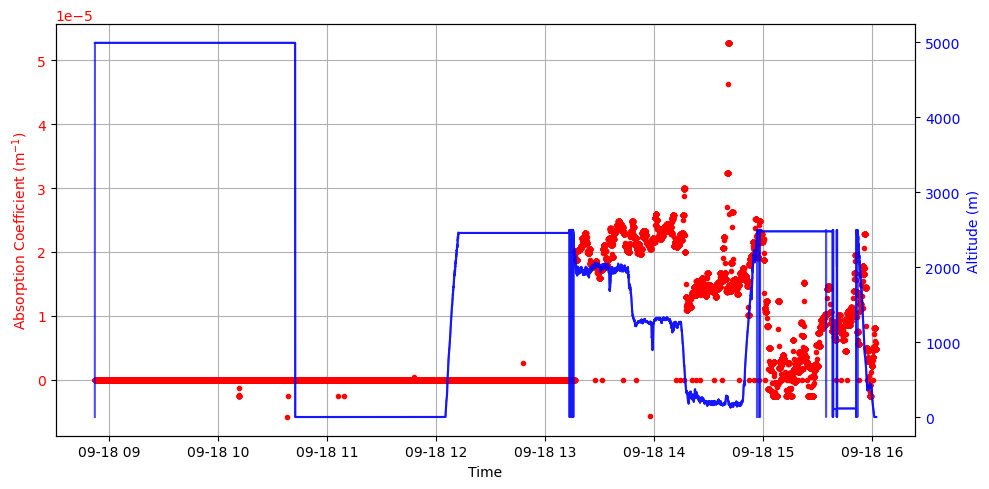

In [28]:
# Create figure and primary y-axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot PSAP_LIN on the primary y-axis
ax1.plot(ds_psap['Time'], ds_psap['PSAP_LIN'], color="r", marker='.', linewidth=0, label='Absorption Coefficient')

ax1.set_xlabel('Time')
ax1.set_ylabel(r'Absorption Coefficient ($\mathrm{m^{-1}}$)', color="r")
ax1.tick_params(axis='y', labelcolor="r")
ax1.grid()

# Create secondary y-axis for height
ax2 = ax1.twinx()
ax2.plot(ds_psap['Time'], ds_psap['HGT_RADR'], color="b", linestyle='-', alpha=0.7, label='Flight Altitude')

ax2.set_ylabel('Altitude (m)', color="b")
ax2.tick_params(axis='y', labelcolor="b")

# Rotate x-axis labels
plt.xticks(rotation=45)

# Tight layout for better formatting
fig.tight_layout()

# Show the plot
plt.show()

In [29]:

def parse_flight_log(lines):
    extracted_data = []
    
    for line in lines[2:]:  # Skip headers
        parts = re.split(r'\s{2,}', line.strip())  # Split on 2+ spaces
        
        if len(parts) < 2:
            continue  # Skip lines with insufficient data
        
        start_time = parts[0]  # First column is always Start Time

        # Check if second column is numeric (End Time), if so, event is at index 2
        if len(parts) > 2 and parts[1].isdigit():
            event = parts[2]  # Third column is the event
        else:
            event = parts[1]  # Otherwise, second column is the event
        
        extracted_data.append([start_time, event])  # Append as list (not tuple)

    return np.array(extracted_data)  # Convert to NumPy array
    
# Read the file
with open(filtered_sum[0], "r") as file:
    lines = file.readlines()
# Process and print output
parsed_data = parse_flight_log(lines)
for row in parsed_data:
    print(row)

['Start' 'End']
['Time' 'Time']
['----' '----']
['114944' 'Start-Up']
['115219' 'power change']
['115451' 'taxy']
['120127' 'pirouette 1']
['120246' 'pirouette 2']
['120506' 'T/O']
['122404' 'Run 1']
['123015' 'Profile 1']
['123533' 'Run 2.1']
['123757' 'Run 2.2']
['124205' 'Run 2.3']
['124402' 'Run 3']
['124650' 'Sonde 1']
['125652' 'Sonde 2']
['130540' 'Profile 2']
['131711' 'Run 4']
['132028' 'sound level']
['134532' 'Profile 3']
['134833' 'Run 5']
['141501' 'Profile 4']
['141900' 'Orbit 1']
['142240' 'Orbit 2']
['142416' 'Run 6']
['144010' 'ovhd fire']
['144109' 'temp']
['144213' 'ovhd fire']
['144907' 'Profile 5']
['150830' 'Run 7']
['152847' 'Profile 6']
['153651' 'Run 8']
['160119' 'Land']


In [30]:
def parse_flight_log(lines):
    extracted_data = []
    
    for line in lines[2:]:  # Skip headers
        parts = re.split(r'\s{2,}', line.strip())  # Split on 2+ spaces
        
        if len(parts) < 2:
            continue  # Skip lines with insufficient data
        
        start_time = parts[0]  # First column is always Start Time

        # Check if second column is numeric (End Time), if so, event is at index 2
        if len(parts) > 2 and parts[1].isdigit():
            event = parts[2]  # Third column is the event
        else:
            event = parts[1]  # Otherwise, second column is the event

        extracted_data.append([start_time, event])  # Append as list (not tuple)
        
    return np.array(extracted_data)  # Convert to NumPy array
    
# Read the file
with open(filtered_sum[0], "r") as file:
    lines = file.readlines()
# Process and print output
parsed_data = parse_flight_log(lines)

start_time_col = parsed_data[3:, 0]  # First column
event_col = parsed_data[3:, 1]  # Second column

# Create DataFrame
df_flight = pd.DataFrame({"Start Time": start_time_col, "Event": event_col})

# Print the DataFrame
print(df_flight)

   Start Time         Event
0      114944      Start-Up
1      115219  power change
2      115451          taxy
3      120127   pirouette 1
4      120246   pirouette 2
5      120506           T/O
6      122404         Run 1
7      123015     Profile 1
8      123533       Run 2.1
9      123757       Run 2.2
10     124205       Run 2.3
11     124402         Run 3
12     124650       Sonde 1
13     125652       Sonde 2
14     130540     Profile 2
15     131711         Run 4
16     132028   sound level
17     134532     Profile 3
18     134833         Run 5
19     141501     Profile 4
20     141900       Orbit 1
21     142240       Orbit 2
22     142416         Run 6
23     144010     ovhd fire
24     144109          temp
25     144213     ovhd fire
26     144907     Profile 5
27     150830         Run 7
28     152847     Profile 6
29     153651         Run 8
30     160119          Land


In [31]:
# Read the file
with open(filtered_sum[0], "r") as file:
    lines = file.readlines()

# Step 1: Extract metadata (first 7 lines)
metadata_lines = lines[:7]

# Step 2: Extract header (8th line)
header_line = lines[7].strip().split()

# Step 3: Extract data (from line 9 onward)
data_lines = lines[9:]

# Step 4: Process each data line
start_time_col = []
event_col = []

for line in data_lines:
    parts = re.split(r'\s{2,}', line.strip())  # Split into at most 4 parts: Time, (optional End Time), Event, and other columns
    
    if len(parts) >= 3:  # Ensure there are at least "Time" and "Event"
        start_time = parts[0]  # First column is the Start Time
        event = parts[2]  # Third column is the Event

        start_time_col.append(start_time)
        event_col.append(event)

# Create a DataFrame
df = pd.DataFrame({"Start Time": start_time_col, "Event": event_col})

# Display the extracted data
print(df)

   Start Time        Event
0      114944     0.28 kft
1      115219     0.27 kft
2      115451     0.27 kft
3      120127  pirouette 1
4      120246  pirouette 2
5      120506     0.25 kft
6      122404        Run 1
7      123015    Profile 1
8      123533      Run 2.1
9      123757      Run 2.2
10     124205      Run 2.3
11     124402        Run 3
12     124650     24.0 kft
13     125652     24.0 kft
14     130540    Profile 2
15     131711        Run 4
16     132028      7.0 kft
17     134532    Profile 3
18     134833        Run 5
19     141501    Profile 4
20     141900      Orbit 1
21     142240      Orbit 2
22     142416        Run 6
23     144010      1.5 kft
24     144109      1.2 kft
25     144213      1.1 kft
26     144907    Profile 5
27     150830        Run 7
28     152847    Profile 6
29     153651        Run 8
30     160119     0.29 kft


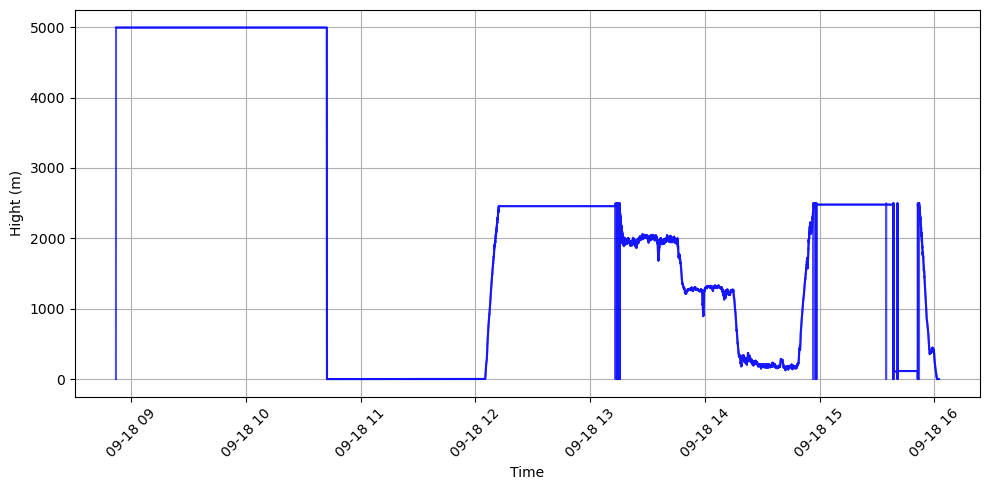

In [32]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

plt.plot(ds_psap['Time'], ds_psap['HGT_RADR'], color="b", linestyle='-', alpha=0.7)

plt.xlabel('Time')
plt.ylabel(r'Hight (m)')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

In [33]:
ds_psap

<xarray.Dataset> Size: 281MB
Dimensions:         (data_point: 25820, sps32: 32, sps04: 4, sps01: 1,
                     sps02: 2, sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/141)
    Time            (data_point) datetime64[ns] 207kB 2012-09-18T08:52:02 ......
    IAS_RVSM        (data_point, sps32) float32 3MB ...
    IAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAS_RVSM        (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAT_DI_R        (data_point, sps32) float32 3MB ...
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 103kB ...
    TDEW_C_U_FLAG   (data_point, sps01) float32 103kB ...
    U_NOTURB        (data_point, sps01) float32 103kB ...
    U_NOTURB_FLAG   (data_point, sps01) float32 103kB ...
    V_NOTURB        (data_point, sps01) float32 103kB ...
    V_NOTURB_FLAG   (data_point, sps01) float32 103kB ...
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b734 on 18-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        08:52:02-16:02:21
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120918_...

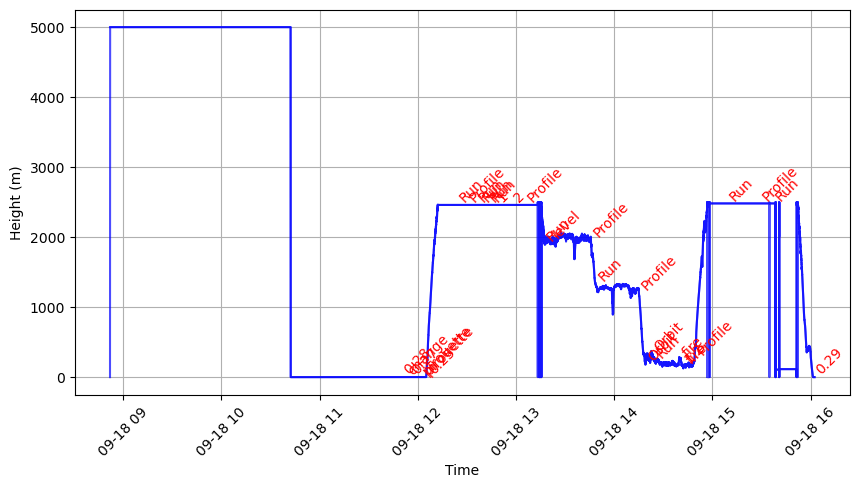

In [82]:
# Step 1: Convert 'Start Time' from HHMMSS to datetime
df["Start Time"] = pd.to_datetime(df["Start Time"], format="%H%M%S")  # Convert HHMMSS to time only
df["Start Time"] = df["Start Time"].apply(lambda t: pd.Timestamp("2012-09-18") + pd.Timedelta(hours=t.hour, minutes=t.minute, seconds=t.second))

# Extract time values from the dataset (since it's a variable, not a dimension)
ds_times = ds_psap["Time"].values  # Convert to NumPy array

# Step 2: Plot the height over time
plt.figure(figsize=(10, 5))

# Plot height (HGT_RADR) over time
plt.plot(ds_times, ds_psap["HGT_RADR"].values, color="b", linestyle="-", alpha=0.7, label="Height")

# Step 3: Overlay event labels
for event_time, event_name in zip(df["Start Time"], df["Event"]):
    # Find the closest time in the dataset
    closest_idx = np.argmin(np.abs(ds_times - np.datetime64(event_time)))  # Index of nearest timestamp
    closest_time = ds_times[closest_idx]
    height_at_time = ds_psap["HGT_RADR"].values[closest_idx][0]  # Get height value

    # Plot event text
    plt.text(closest_time, height_at_time, event_name, fontsize=10, color="red", ha="left", va="bottom", rotation=45)

# Labels and formatting
plt.xlabel("Time")
plt.ylabel(r"Height (m)")
plt.xticks(rotation=45)
plt.grid()
#plt.legend()

# Tight layout for better plot formatting
#plt.tight_layout()

# Show the plot
plt.show()

In [130]:
# Assuming df is your DataFrame and has columns "Start Time" and "Event"
start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]

# Print the extracted start time
print(start_up_time)

2012-09-18 11:49:44


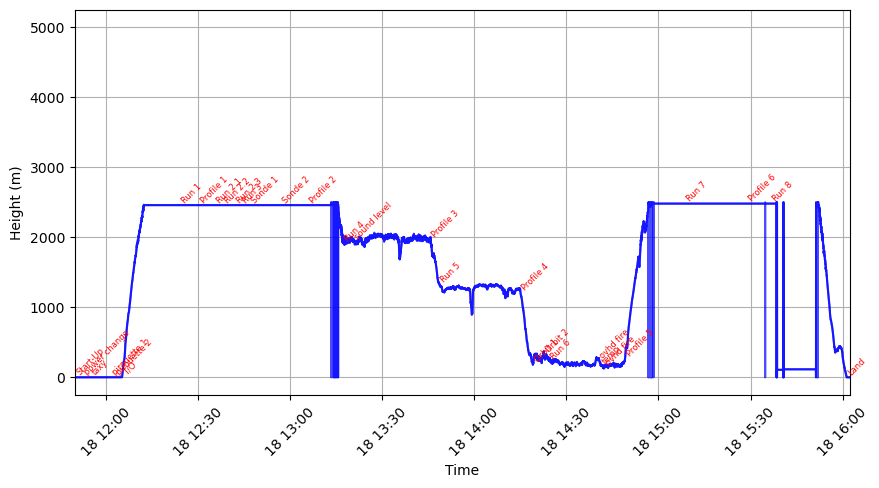

In [138]:
# Step 1: Convert 'Start Time' from HHMMSS to datetime
df_flight["Start Time"] = pd.to_datetime(df_flight["Start Time"], format="%H%M%S")  # Convert HHMMSS to time only
df_flight["Start Time"] = df_flight["Start Time"].apply(lambda t: pd.Timestamp("2012-09-18") + pd.Timedelta(hours=t.hour, minutes=t.minute, seconds=t.second))

# Extract time values from the dataset (since it's a variable, not a dimension)
ds_times = ds_psap["Time"].values  # Convert to NumPy array

# Step 2: Plot the height over time
plt.figure(figsize=(10, 5))

# Plot height (HGT_RADR) over time
plt.plot(ds_times, ds_psap["HGT_RADR"].values, color="b", linestyle="-", alpha=0.7, label="Height")

# Step 3: Overlay event labels
for event_time, event_name in zip(df_flight["Start Time"], df_flight["Event"]):
    # Find the closest time in the dataset
    closest_idx = np.argmin(np.abs(ds_times - np.datetime64(event_time)))  # Index of nearest timestamp
    closest_time = ds_times[closest_idx]
    height_at_time = ds_psap["HGT_RADR"].values[closest_idx][0]  # Get height value

    # Plot event text
    plt.text(closest_time, height_at_time, event_name, fontsize=6, color="red", ha="left", va="bottom", rotation=45)


# Assuming df is your DataFrame and has columns "Start Time" and "Event"
start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]

# Set xlim to start at 11:40
plt.xlim(start_up_time, ds_times[-1])  # ds_times[-1] is the last time value

# Labels and formatting
plt.xlabel("Time")
plt.ylabel(r"Height (m)")
plt.xticks(rotation=45)
plt.grid()
#plt.legend()

# Tight layout for better plot formatting
#plt.tight_layout()

# Show the plot
plt.show()

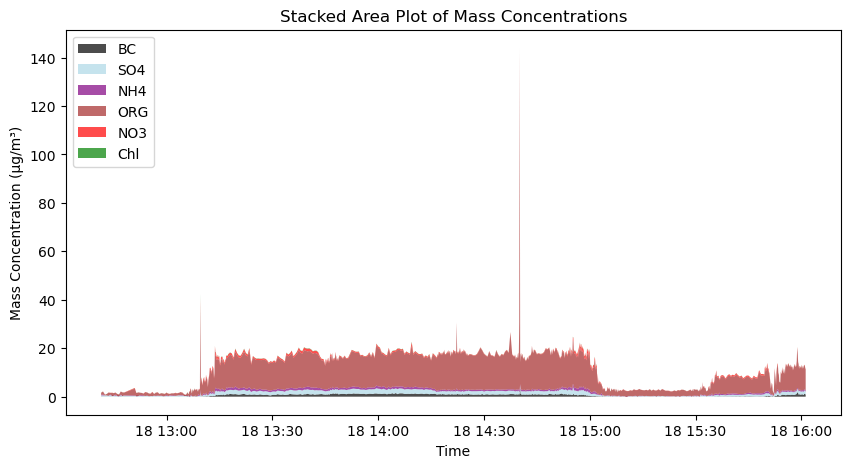

In [34]:
area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_psap)
#labels = ["BC", "SO4", "NH4", "ORG", "NO3", "Chl"]
#colors = ["black", "blue", "green", "orange", "red", "purple"]  # Assign colors
labels = ["BC", "SO4", "NH4", "ORG", "NO3", "Chl"]
colors = ["black", "lightblue", "purple", "brown", "red", "green"]
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(area_time, data_mass_concentration, labels=labels, colors=colors, alpha=0.7)

# Labels and legend
ax.set_xlabel("Time")
ax.set_ylabel("Mass Concentration (µg/m³)")
ax.set_title("Stacked Area Plot of Mass Concentrations")
ax.legend(loc="upper left")

plt.show()

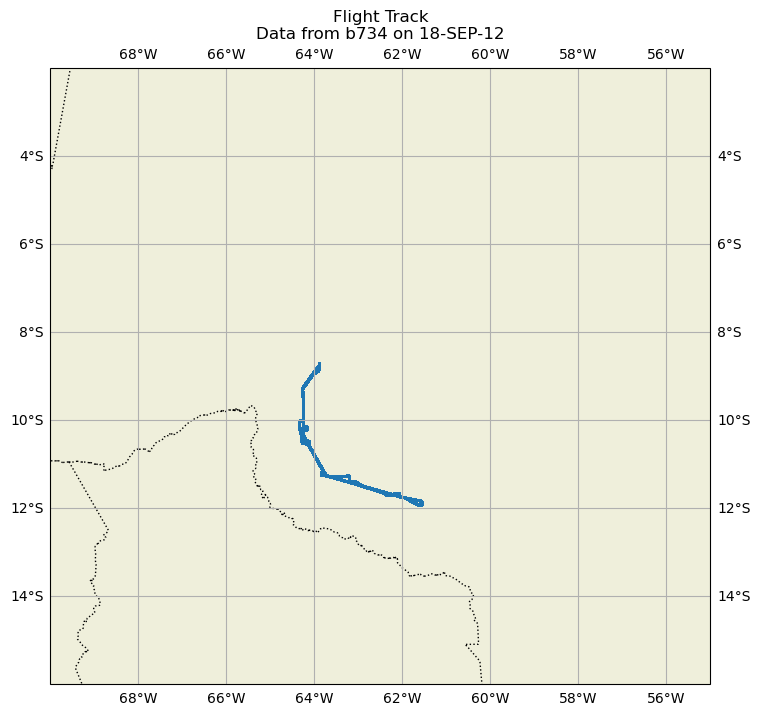

In [35]:
# Create a figure and axis with a Cartopy map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Filter valid points (assuming 1 means valid, adjust this logic based on your flag meaning)
valid_points_lat = ds_psap['LAT_GIN_FLAG'].values == 1
valid_points_lon = ds_psap['LON_GIN_FLAG'].values == 1
# Select only valid latitude and longitude points using numpy boolean indexing
lat_valid = ds_psap['LAT_GIN'].values[valid_points_lat]
lon_valid = ds_psap['LON_GIN'].values[valid_points_lon]

# Set map extent (adjust based on the region you're plotting)
ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.gridlines(draw_labels=True)

# Loop through each dataset to plot flight tracks
#for file in (file_paths):
#ds = xr.open_dataset(file)

# Extract latitude and longitude for the current dataset
lat = ds_psap['LAT_GIN'].values.flatten()
lon = ds_psap['LON_GIN'].values.flatten()

# Get the title for the current dataset to use as a label
track_title = ds_psap.attrs.get('title', 'Unknown Track')

# Plot the latitude and longitude points for the current flight track
ax.scatter(lon, lat, s=1, transform=ccrs.PlateCarree())

# Optionally add a title and legend
plt.title('Flight Track\n'+track_title)
#plt.legend(loc='upper right')

# Show the plot
plt.show()

In [36]:
print(lon_valid.min()-8)
print(lon_valid.max()+8)
print(lat_valid.min()-8)
print(lat_valid.max()+8)

-71.89973449707031
-55.89967346191406
-16.715465545654297
-0.7154083251953125


In [37]:
valid_PSAP_mask = ds_test["PSAP_LIN_FLAG"] == 0
filtered_ds_psap = ds_test.where(valid_PSAP_mask, drop=False)
filtered_ds_psap_aux = ds_test.where(valid_PSAP_mask, drop=True)
# Create a boolean mask as an Xarray DataArray
# Ensure both arrays are 1D and aligned
psap_values = filtered_ds_psap["PSAP_LIN"].values.squeeze()
tm_values = tm_test.squeeze()

# Perform element-wise division, ignoring NaNs
result = np.divide(psap_values, tm_values*1e-6)

# Drop NaN values from the result if needed
Mass_absortion_eff = result.where(~np.isnan(result), drop=True)

In [38]:
#print(filtered_ds_psap_aux['Time'])
print(ds_neph['datetime'])

<xarray.DataArray 'datetime' (datetime: 21520)> Size: 172kB
array(['2012-09-18T10:12:24.000000000', '2012-09-18T10:12:25.000000000',
       '2012-09-18T10:12:26.000000000', ..., '2012-09-18T16:11:01.000000000',
       '2012-09-18T16:11:02.000000000', '2012-09-18T16:11:03.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * datetime  (datetime) datetime64[ns] 172kB 2012-09-18T10:12:24 ... 2012-09...


In [39]:
print(filtered_ds_psap_aux['Time'])

<xarray.DataArray 'Time' (data_point: 648, sps01: 1)> Size: 5kB
array([['2012-09-18T13:16:24.000000000'],
       ['2012-09-18T13:16:32.000000000'],
       ['2012-09-18T13:16:40.000000000'],
       ['2012-09-18T13:16:48.000000000'],
       ['2012-09-18T13:16:56.000000000'],
       ['2012-09-18T13:17:04.000000000'],
       ['2012-09-18T13:17:12.000000000'],
       ['2012-09-18T13:17:19.000000000'],
       ['2012-09-18T13:17:30.000000000'],
       ['2012-09-18T13:18:00.000000000'],
       ['2012-09-18T13:18:30.000000000'],
       ['2012-09-18T13:19:00.000000000'],
       ['2012-09-18T13:19:30.000000000'],
       ['2012-09-18T13:20:00.000000000'],
       ['2012-09-18T13:20:30.000000000'],
       ['2012-09-18T13:21:00.000000000'],
       ['2012-09-18T13:21:30.000000000'],
       ['2012-09-18T13:22:00.000000000'],
       ['2012-09-18T13:22:30.000000000'],
       ['2012-09-18T13:23:00.000000000'],
...
       ['2012-09-18T15:58:40.000000000'],
       ['2012-09-18T15:58:48.000000000'],
       [

/tmp/ipykernel_384/1271835049.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)
/tmp/ipykernel_384/1271835049.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)
/tmp/ipykernel_384/1271835049.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)
/tmp/ipykernel_384/1271835049.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)


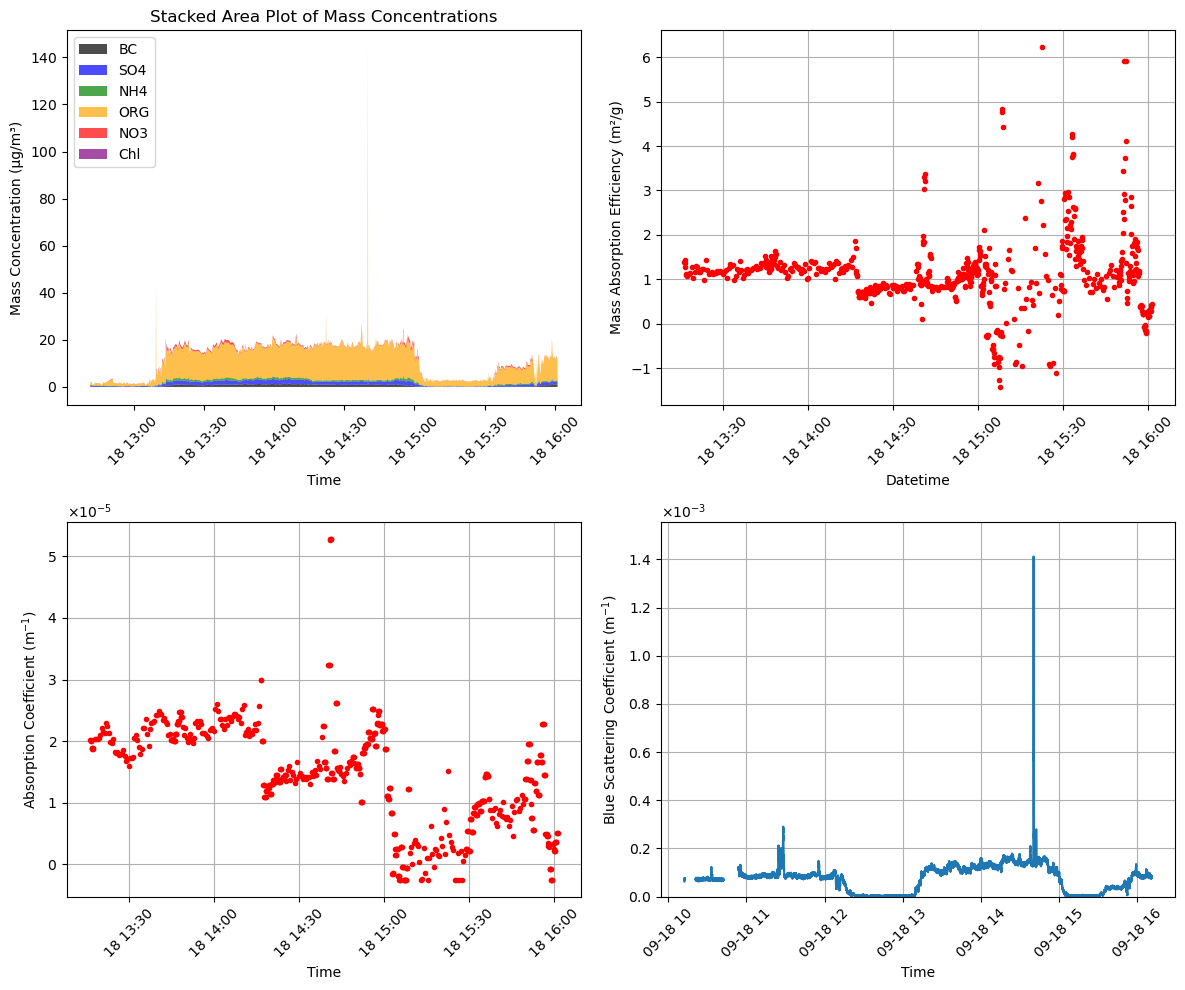

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns
formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))  # Force scientific notation when appropriate

# First plot - Stacked Area Plot
labels = ["BC", "SO4", "NH4", "ORG", "NO3", "Chl"]
colors = ["black", "blue", "green", "orange", "red", "purple"]
axes[0, 0].stackplot(area_time, data_mass_concentration, labels=labels, colors=colors, alpha=0.7)
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Mass Concentration (µg/m³)")
axes[0, 0].set_title("Stacked Area Plot of Mass Concentrations")
axes[0, 0].legend(loc="upper left")
axes[0, 0].yaxis.set_major_formatter(formatter)  # Apply scientific notation
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# Second plot - Mass Absorption Efficiency over Time
axes[0, 1].plot(filtered_ds_psap_aux['Time'].squeeze(), Mass_absortion_eff, color="r", marker='.', linewidth=0)
axes[0, 1].set_xlabel("Datetime")
axes[0, 1].set_ylabel("Mass Absorption Efficiency (m²/g)")
axes[0, 1].yaxis.set_major_formatter(formatter)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)
axes[0, 1].grid()

# Third plot - Absorption Coefficient
axes[1, 0].plot(filtered_ds_psap_aux['Time'], filtered_ds_psap_aux['PSAP_LIN'], color="r", marker='.', linewidth=0)
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel(r'Absorption Coefficient ($\mathrm{m^{-1}}$)')
axes[1, 0].yaxis.set_major_formatter(formatter)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)
axes[1, 0].grid()

# Fourth plot - Blue Scattering Coefficient
axes[1, 1].plot(ds_neph['datetime'], ds_neph['TSC_BLUU'])
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel(r'Blue Scattering Coefficient ($\mathrm{m^{-1}}$)')
axes[1, 1].set_ylim(0, np.max(ds_neph['TSC_BLUU']) * 1.1)
axes[1, 1].yaxis.set_major_formatter(formatter)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)
axes[1, 1].grid()

# Adjust layout
plt.tight_layout()

# Show the final combined figure
plt.show()

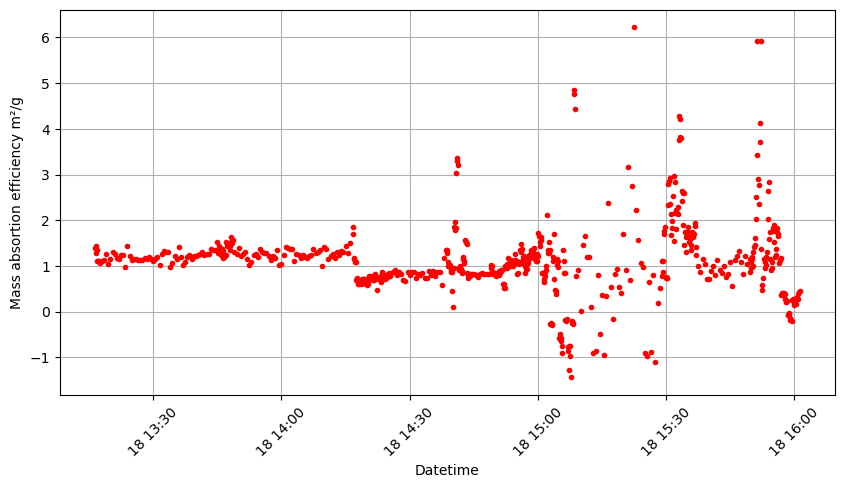

In [41]:
# Plot SO4 vs. datetime
plt.figure(figsize=(10, 5))
plt.plot(filtered_ds_psap_aux['Time'].squeeze(), Mass_absortion_eff, color="r", marker='.',linewidth=0)
#plt.xlim(filtered_ds_psap['Time'][550],filtered_ds_psap['Time'][3000])

# Formatting
plt.xlabel("Datetime")
plt.ylabel("Mass absortion efficiency m²/g")
#plt.title("Mass absortion efficiency Over Time")
plt.xticks(rotation=45)
plt.grid()

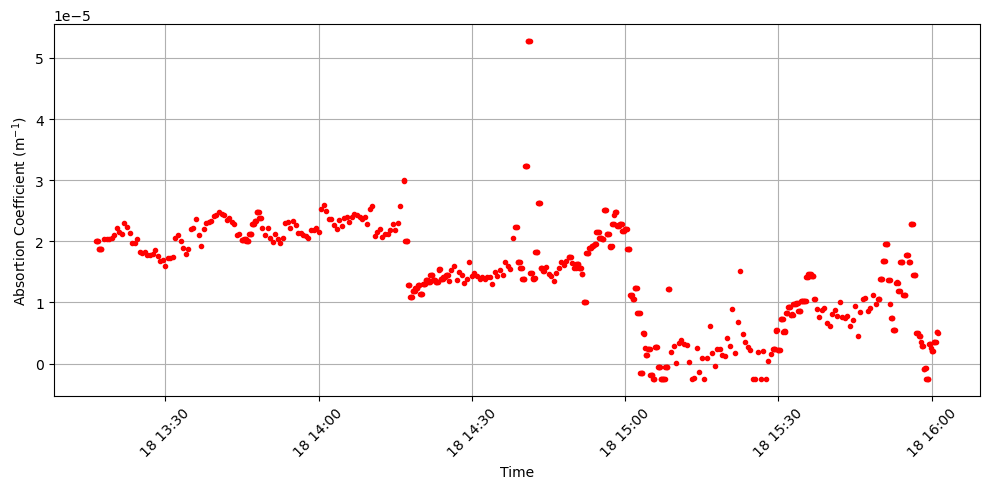

In [42]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(filtered_ds_psap_aux['Time'], filtered_ds_psap_aux['PSAP_LIN'], color="r", marker='.',linewidth=0)
#plt.plot(ds_test['Time'], ds_test['PSAP_LIN'], color="b", marker='o', linestyle='', markersize=4)
#plt.xlim(ds_test['Time'][200],ds_test['Time'][3500])
plt.xlabel('Time')
plt.ylabel(r'Absortion Coefficient ($\mathrm{m^{-1}}$)')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

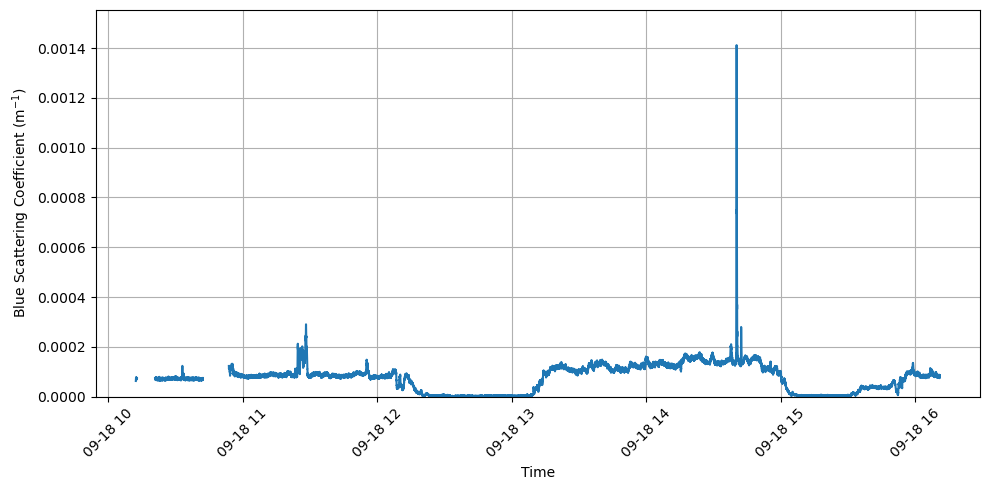

In [43]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(ds_neph['datetime'], ds_neph['TSC_BLUU'])

plt.xlabel('Time')
plt.ylabel(r'Blue Scattering Coefficient ($\mathrm{m^{-1}}$)')
plt.ylim(0,np.max(ds_neph['TSC_BLUU'])*1.1)
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

In [44]:
# Compute the mean, handling cases where the list might be empty
mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff) 
std_mass_absorption_eff_g = np.nanstd(Mass_absortion_eff) 
mean_std = std_mass_absorption_eff_g/np.sqrt(len(Mass_absortion_eff))

# Print results
print(f"Mean Mass Absortion Efficiency (g): {mean_mass_absorption_eff_g:.3f} m²/g")
print(f"Standard Deviation: {std_mass_absorption_eff_g:.3f} m²/g")
print(f"Mean Standard Deviation: {mean_std:.3f} m²/g")

Mean Mass Absortion Efficiency (g): 1.115 m²/g
Standard Deviation: 0.833 m²/g
Mean Standard Deviation: 0.033 m²/g


In [45]:
def plot_flight_data(flight_number, 
                     area_time, data_mass_concentration, 
                     filtered_ds_psap_aux, Mass_absortion_eff, 
                     filtered_ds_psap_aux_PSAP_LIN, 
                     ds_neph_datetime, ds_neph_TSC_BLUU):
    
    # Create a figure with 2 rows, 2 columns
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))  # Force scientific notation when needed
    
    # First plot - Stacked Area Plot
    labels = ["BC", "SO4", "NH4", "ORG", "NO3", "Chl"]
    colors = ["black", "lightblue", "purple", "brown", "red", "green"]
    axes[0, 0].stackplot(area_time, data_mass_concentration, labels=labels, colors=colors, alpha=0.7)
    axes[0, 0].set_xlabel("Time")
    axes[0, 0].set_ylabel("Mass Concentration (µg/m³)")
    axes[0, 0].set_title(f"Flight {flight_number} - Mass Concentrations")
    axes[0, 0].legend(loc="upper left")
    axes[0, 0].yaxis.set_major_formatter(formatter)  # Apply scientific notation
    axes[0, 0].tick_params(axis='x', rotation=45)

    # Second plot - Mass Absorption Efficiency over Time
    axes[0, 1].plot(filtered_ds_psap_aux['Time'].squeeze(), Mass_absortion_eff, color="r", marker='.', linewidth=0)
    axes[0, 1].set_xlabel("Datetime")
    axes[0, 1].set_ylabel("Mass Absorption Efficiency (m²/g)")
    axes[0, 1].set_title(f"Flight {flight_number} - Mass Absorption Efficiency")
    axes[0, 1].yaxis.set_major_formatter(formatter)
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid()

    # Third plot - Absorption Coefficient
    axes[1, 0].plot(filtered_ds_psap_aux['Time'], filtered_ds_psap_aux_PSAP_LIN, color="r", marker='.', linewidth=0)
    axes[1, 0].set_xlabel("Time")
    axes[1, 0].set_ylabel(r'Absorption Coefficient ($\mathrm{m^{-1}}$)')
    axes[1, 0].set_title(f"Flight {flight_number} - Absorption Coefficient")
    axes[1, 0].yaxis.set_major_formatter(formatter)
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid()

    # Fourth plot - Blue Scattering Coefficient
    axes[1, 1].plot(ds_neph_datetime, ds_neph_TSC_BLUU)
    axes[1, 1].set_xlabel("Time")
    axes[1, 1].set_ylabel(r'Blue Scattering Coefficient ($\mathrm{m^{-1}}$)')
    axes[1, 1].set_title(f"Flight {flight_number} - Blue Scattering Coefficient")
    axes[1, 1].set_ylim(0, np.max(ds_neph_TSC_BLUU) * 1.1)
    axes[1, 1].yaxis.set_major_formatter(formatter)
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid()

    # Adjust layout and save figure
    plt.tight_layout()
    file_name = f"flight_{flight_number}.png"
    plt.savefig('./Flights_plots/'+file_name, dpi=300)  # Save with high resolution
    print(f"Figure saved as {file_name}")

    # Show the final combined figure
    plt.show()
    return

In [60]:
def plot_flight_data_v2(flight_number, 
                     area_time, data_mass_concentration, 
                     filtered_ds_psap_aux, Mass_absortion_eff, 
                     filtered_ds_psap_aux_PSAP_LIN, 
                     ds_neph_datetime, ds_neph_TSC_BLUU,
                     ds_psap, df_flight, minlon, maxlon, minlat, maxlat):
    
    fig = plt.figure(figsize=(14, 15))

    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    
    # Define plot positions
    positions = {
        "stacked": [0.05, 0.7, 0.4, 0.25],   # Left, Bottom, Width, Height
        "abs_eff": [0.55, 0.7, 0.4, 0.25],
        "abs_coef": [0.05, 0.4, 0.4, 0.25],
        "scatter_coef": [0.55, 0.4, 0.4, 0.25],
        "map": [0.05, 0.1, 0.4, 0.25],
        "height_time": [0.55, 0.1, 0.4, 0.25],
    }

    # First plot - Stacked Area Plot
    ax1 = fig.add_axes(positions["stacked"])
    labels = ["BC", "SO4", "NH4", "ORG", "NO3", "Chl"]
    colors = ["black", "lightblue", "purple", "brown", "red", "green"]
    ax1.stackplot(area_time, data_mass_concentration, labels=labels, colors=colors, alpha=0.7)
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Mass Concentration (µg/m³)")
    ax1.set_title(f"Flight {flight_number} - Mass Concentrations")
    ax1.legend(loc="upper left")
    ax1.yaxis.set_major_formatter(formatter)
    ax1.tick_params(axis='x', rotation=45)

    # Second plot - Mass Absorption Efficiency over Time
    ax2 = fig.add_axes(positions["abs_eff"])
    ax2.plot(filtered_ds_psap_aux['Time'].squeeze(), Mass_absortion_eff, color="r", marker='.', linewidth=0)
    ax2.set_xlabel("Datetime")
    ax2.set_ylabel("Mass Absorption Efficiency (m²/g)")
    ax2.set_title(f"Flight {flight_number} - Mass Absorption Efficiency")
    ax2.yaxis.set_major_formatter(formatter)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid()

    # Third plot - Absorption Coefficient
    ax3 = fig.add_axes(positions["abs_coef"])
    ax3.plot(filtered_ds_psap_aux['Time'], filtered_ds_psap_aux_PSAP_LIN, color="r", marker='.', linewidth=0)
    ax3.set_xlabel("Time")
    ax3.set_ylabel(r'Absorption Coefficient ($\mathrm{m^{-1}}$)')
    ax3.set_title(f"Flight {flight_number} - Absorption Coefficient")
    ax3.yaxis.set_major_formatter(formatter)
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid()

    # Fourth plot - Blue Scattering Coefficient
    ax4 = fig.add_axes(positions["scatter_coef"])
    ax4.plot(ds_neph_datetime, ds_neph_TSC_BLUU)
    ax4.set_xlabel("Time")
    ax4.set_ylabel(r'Blue Scattering Coefficient ($\mathrm{m^{-1}}$)')
    ax4.set_title(f"Flight {flight_number} - Blue Scattering Coefficient")
    ax4.set_ylim(0, np.max(ds_neph_TSC_BLUU) * 1.1)
    ax4.yaxis.set_major_formatter(formatter)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid()

    # Fifth plot - Flight Track Map (Cartopy)
    ax5 = fig.add_axes(positions["map"], projection=ccrs.PlateCarree())
    ax5.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    ax5.coastlines()
    ax5.add_feature(cfeature.BORDERS, linestyle=':')
    ax5.add_feature(cfeature.LAND)
    ax5.add_feature(cfeature.OCEAN)
    ax5.gridlines(draw_labels=True)

    valid_points_lat = ds_psap['LAT_GIN_FLAG'].values == 1
    valid_points_lon = ds_psap['LON_GIN_FLAG'].values == 1
    lat_valid = ds_psap['LAT_GIN'].values[valid_points_lat]
    lon_valid = ds_psap['LON_GIN'].values[valid_points_lon]

    ax5.scatter(lon_valid, lat_valid, s=1, transform=ccrs.PlateCarree())
    ax5.set_title(f"Flight {flight_number} - Flight Track")


    # Sixth plot - Height over Time with Event Labels
    ax6 = fig.add_axes(positions["height_time"])
    ax6.plot(ds_psap['Time'].values, ds_psap['HGT_RADR'].values, color="b", linestyle="-", alpha=0.7, label="Height")
    for event_time, event_name in zip(df_flight["Start Time"], df_flight["Event"]):
        closest_idx = np.argmin(np.abs(ds_psap['Time'].values - np.datetime64(event_time)))
        closest_time = ds_psap['Time'].values[closest_idx]
        height_at_time = ds_psap['HGT_RADR'].values[closest_idx][0]
        ax6.text(closest_time, height_at_time, event_name, fontsize=6, color="red", ha="left", va="bottom", rotation=45)
    start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]
    ax6.set_xlim(start_up_time, ds_psap['Time'].values[-1])
    ax6.set_xlabel("Time")
    ax6.set_ylabel("Height (m)")
    ax6.tick_params(axis='x', rotation=45)
    ax6.grid()
    ax6.set_title(f"Flight {flight_number} - Height over Time")

    # Save and show the figure
    plt.savefig(f'./Flights_plots/flight_{flight_number}_v2.png', dpi=300)
    print(f"Figure saved as flight_{flight_number}_v2.png")
    plt.show()

    return

/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/mo-non-core/metoffice-neph1_faam_20120918_r1_b734.nc


ValueError: x and y can be no greater than 2D, but have shapes (648, 1) and (648, 2, 1)

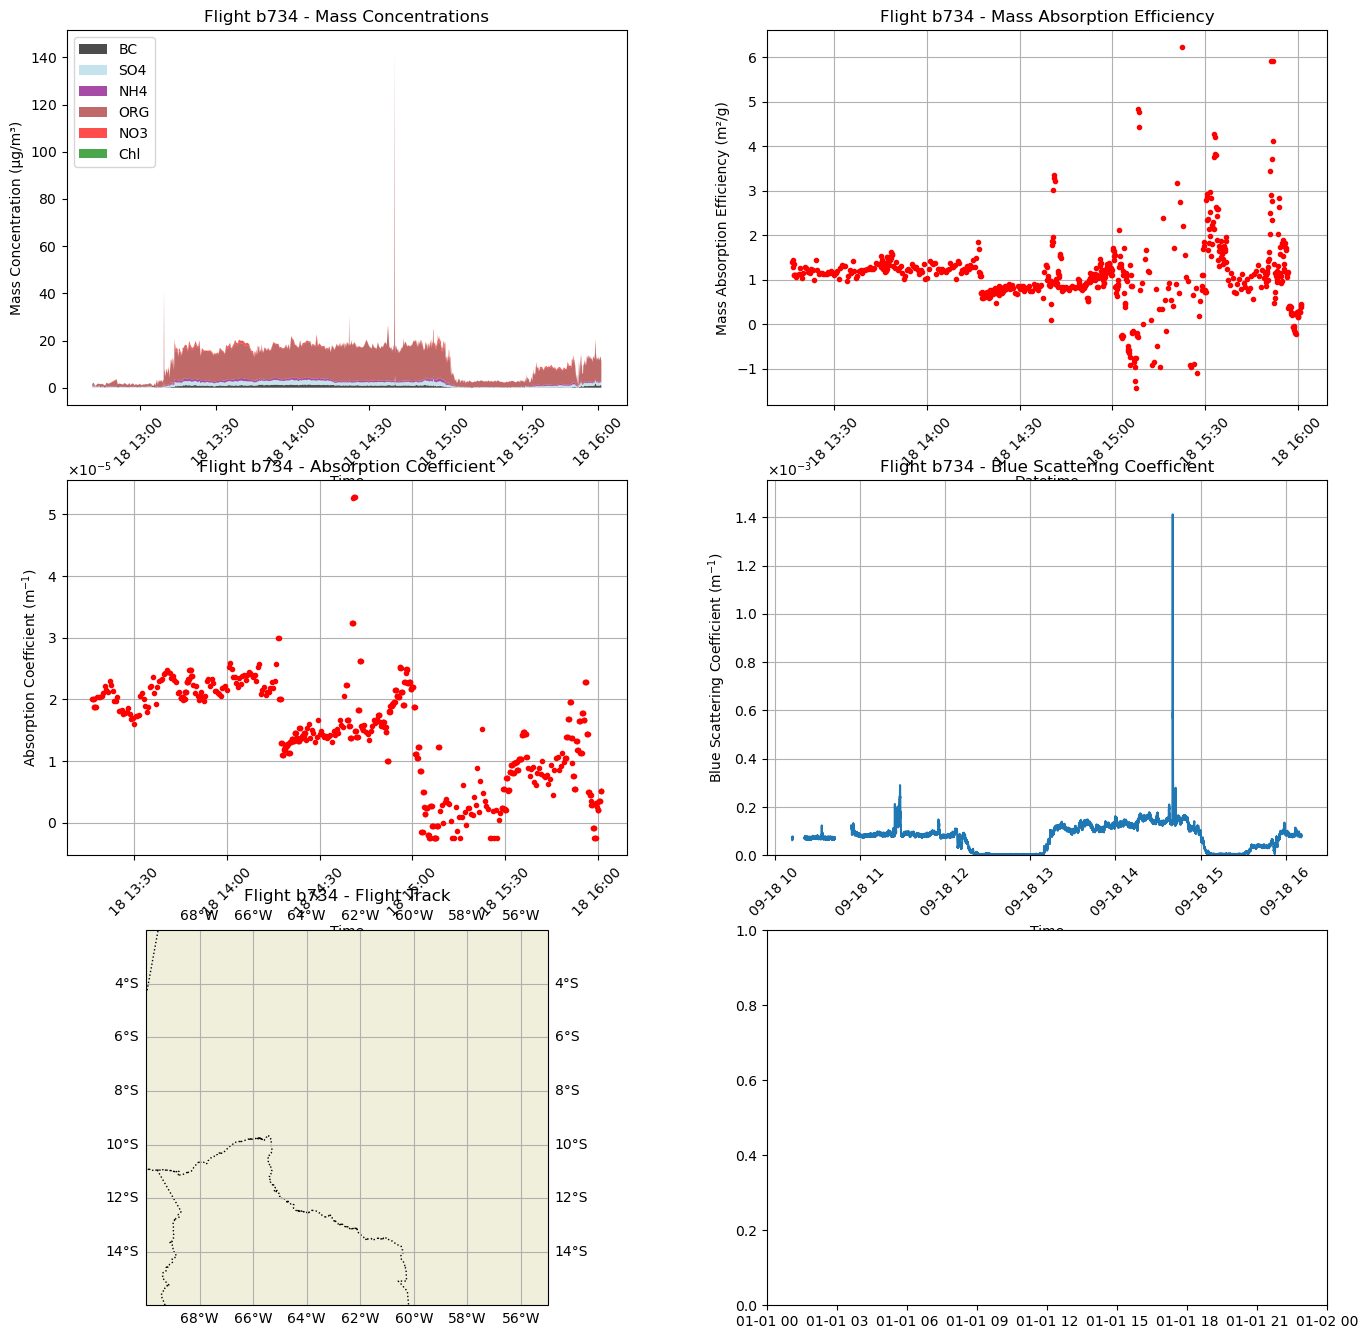

In [61]:
# List to store results
results = []

# Iterate over all matching flights
for sp2_file, ams_file, nc_file, neph_file in zip(filtered_sp2, filtered_ams, filtered_nc, filtered_neph):

    print(neph_file)
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_psap = xr.open_dataset(nc_file)

    #Calculate absortion efficiency 
    ds_test,tm_test=calculate_absortion_eff(ds_sp2,ds_ams,ds_psap)

    #Extract concentration data
    area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_psap)

    #Filter absortion data
    valid_PSAP_mask = ds_test["PSAP_LIN_FLAG"] == 0
    filtered_ds_psap = ds_test.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = ds_test.where(valid_PSAP_mask, drop=True)
    # Ensure both arrays are 1D and aligned
    psap_values = filtered_ds_psap["PSAP_LIN"].values.squeeze()
    tm_values = tm_test.squeeze()
    
    # Perform element-wise division, ignoring NaNs
    result = np.divide(psap_values, tm_values*1e-6)
    
    # Drop NaN values from the result if needed
    Mass_absortion_eff = result.where(~np.isnan(result), drop=True)

    # Compute the mean, handling cases where the list might be empty
    mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff) 
    std_mass_absorption_eff_g = np.nanstd(Mass_absortion_eff) 
    mean_std = std_mass_absorption_eff_g/np.sqrt(len(Mass_absortion_eff))
    

    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"

    # Plot results
    #plot_flight_data(
    #    flight_number=flight_number,
    #    area_time=area_time,
    #    data_mass_concentration=data_mass_concentration,
    #    filtered_ds_psap_aux=filtered_ds_psap_aux,
    #    Mass_absortion_eff=Mass_absortion_eff,
    #    filtered_ds_psap_aux_PSAP_LIN=filtered_ds_psap_aux['PSAP_LIN'],
    #    ds_neph_datetime=ds_neph['datetime'],
    #    ds_neph_TSC_BLUU=ds_neph['TSC_BLUU']
    #)
    plot_flight_data_v2( 
        flight_number=flight_number,
        area_time=area_time,
        data_mass_concentration=data_mass_concentration,
        filtered_ds_psap_aux=filtered_ds_psap_aux,
        Mass_absortion_eff=Mass_absortion_eff,
        filtered_ds_psap_aux_PSAP_LIN=filtered_ds_psap_aux['PSAP_LIN'],
        ds_neph_datetime=ds_neph['datetime'],
        ds_neph_TSC_BLUU=ds_neph['TSC_BLUU'],
        ds_psap=filtered_ds_psap_aux, 
        df_flight=df_flight, 
        minlon = minlon, 
        maxlon = maxlon,
        minlat = minlat, 
        maxlat = maxlat)
    

    # Store results in a list
    results.append({
        "flight": flight_number,
        "mean_mass_absorption_eff_g": mean_mass_absorption_eff_g,
        "std_mass_absorption_eff_g": std_mass_absorption_eff_g,
        "mean_std": mean_std,
        "N": len(Mass_absortion_eff)
    })

In [ ]:
# Print results
for res in results:
    print(f"Flight {res['flight']}: {res['mean_mass_absorption_eff_g']:.3f} m²/g")

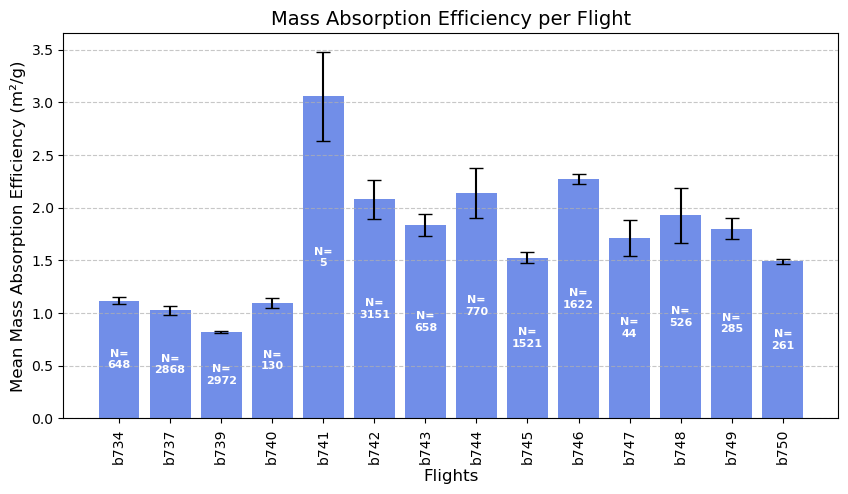

In [31]:
# Extract flight numbers, mean values, standard deviation, and N
flight_numbers = [res["flight"] for res in results]
mean_mass_absorption_eff_g_values = [res["mean_mass_absorption_eff_g"] for res in results]
mean_std_values = [res["mean_std"] for res in results]  # Error bars
n_values = [res["N"] for res in results]  # Number of measurements

# Create the plot
plt.figure(figsize=(10, 5))
bars = plt.bar(
    flight_numbers,
    mean_mass_absorption_eff_g_values,
    yerr=mean_std_values,  # Add error bars
    capsize=5,  # Add caps on error bars
    color='royalblue',
    alpha=0.75
)

# Labels and title
plt.xlabel("Flights", fontsize=12)
plt.ylabel("Mean Mass Absorption Efficiency (m²/g)", fontsize=12)
plt.title("Mass Absorption Efficiency per Flight", fontsize=14)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text inside the bars to show N
for bar, n in zip(bars, n_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height/2, f"N=\n{n}", ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Show the plot
plt.savefig('Absortion effiency.png')